In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
BASE = "https://storage.googleapis.com/dm-meshgraphnets/cylinder_flow/"
os.makedirs("cf", exist_ok=True)
for f in ["meta.json", "test.tfrecord"]:
    if not os.path.exists(f"cf/{f}"):
        !wget -q -O cf/{f} {BASE}{f}
    print(f, os.path.getsize(f"cf/{f}")//1024, "KB")

meta.json 0 KB
test.tfrecord 1323609 KB


In [3]:
import json, tensorflow as tf, numpy as np

meta = json.load(open("cf/meta.json"))

def parse(proto, meta):
    feats = {k: tf.io.VarLenFeature(tf.string) for k in meta["field_names"]}
    d = tf.io.parse_single_example(proto, feats)
    out = {}
    for key, field in meta["features"].items():
        x = tf.io.decode_raw(d[key].values, getattr(tf, field["dtype"]))
        x = tf.reshape(x, field["shape"])
        if field["type"] == "static":                 # mesh_pos, cells, node_type
            x = tf.tile(x, [meta["trajectory_length"], 1, 1])
        out[key] = x
    return out

ds = tf.data.TFRecordDataset("cf/test.tfrecord").map(lambda p: parse(p, meta))
traj = next(iter(ds))
pos   = traj["mesh_pos"][0].numpy()     # [n,2]  node positions (fixed over time)
cells = traj["cells"][0].numpy()        # [n_cells,3]  triangles
vel   = traj["velocity"].numpy()        # [T, n, 2]  velocity at every node, every frame
print("nodes:", pos.shape[0], " cells:", cells.shape[0], " frames:", vel.shape[0])

I0000 00:00:1788146238.121105      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788146238.124015      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


nodes: 1923  cells: 3612  frames: 600


graph: 1923 nodes, 5535 edges


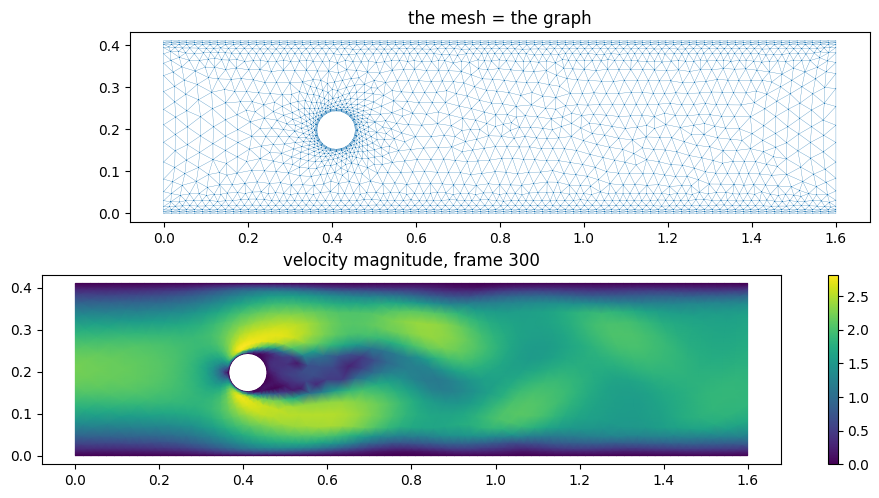

In [4]:
import matplotlib.pyplot as plt, matplotlib.tri as mtri

e = np.concatenate([cells[:,[0,1]], cells[:,[1,2]], cells[:,[2,0]]], 0)
e = np.unique(np.sort(e,1), axis=0)
print("graph:", pos.shape[0], "nodes,", e.shape[0], "edges")

t = mtri.Triangulation(pos[:,0], pos[:,1], cells)
fig, ax = plt.subplots(2,1, figsize=(10,5))
ax[0].triplot(t, lw=0.2); ax[0].set_aspect("equal"); ax[0].set_title("the mesh = the graph")
speed = np.linalg.norm(vel[300], axis=1)                 # frame 300
tp = ax[1].tripcolor(t, speed, shading="gouraud"); ax[1].set_aspect("equal")
ax[1].set_title("velocity magnitude, frame 300"); fig.colorbar(tp, ax=ax[1])
plt.tight_layout(); plt.show()

In [5]:
import torch, torch.nn as nn

pos   = torch.tensor(traj["mesh_pos"][0].numpy())          # [n,2] fixed geometry
ntype = torch.tensor(traj["node_type"][0].numpy()).squeeze(-1).long()  # [n]
velT  = torch.tensor(traj["velocity"].numpy())             # [T,n,2]
NUM_TYPES = 9

c = torch.tensor(cells.astype("int64"))
e = torch.cat([c[:,[0,1]], c[:,[1,2]], c[:,[2,0]]], 0)
e = torch.cat([e, e.flip(1)], 0).unique(dim=0)             # bidirectional
edge_index = e.t().contiguous()                            # [2,E]
src, dst = edge_index

t = 300
node_feats = torch.cat([velT[t], torch.nn.functional.one_hot(ntype, NUM_TYPES).float()], 1)  # [n,11]
rel = pos[src] - pos[dst]
edge_feats = torch.cat([rel, rel.norm(dim=1, keepdim=True)], 1)      # [E,3]
target = velT[t+1] - velT[t]                                # [n,2]  <- what we predict
print(node_feats.shape, edge_index.shape, edge_feats.shape, target.shape)

torch.Size([1923, 11]) torch.Size([2, 11070]) torch.Size([11070, 3]) torch.Size([1923, 2])


In [6]:
def mlp(i, o, h=128): return nn.Sequential(nn.Linear(i,h), nn.ReLU(), nn.Linear(h,o))
LAT = 128
node_encoder = mlp(node_feats.shape[1], LAT)
edge_encoder = mlp(edge_feats.shape[1], LAT)
h_node = node_encoder(node_feats)     # [n,128]
h_edge = edge_encoder(edge_feats)     # [E,128]
print(h_node.shape, h_edge.shape)

torch.Size([1923, 128]) torch.Size([11070, 128])


In [7]:
def mlp(i, o, h=128): return nn.Sequential(nn.Linear(i,h), nn.ReLU(), nn.Linear(h,o))

class GraphNetBlock(nn.Module):
    def __init__(self, lat=128):
        super().__init__()
        self.edge_mlp = mlp(3*lat, lat)   # sees [edge, sender, receiver]
        self.node_mlp = mlp(2*lat, lat)   # sees [node, summed messages]
    def forward(self, h_node, h_edge, edge_index):
        s, d = edge_index
        edge_in = torch.cat([h_edge, h_node[s], h_node[d]], dim=1)  # 1. build message inputs
        e_upd   = self.edge_mlp(edge_in)                           #    the message per edge
        agg     = torch.zeros_like(h_node).index_add_(0, d, e_upd) # 2. sum messages at receiver d
        node_in = torch.cat([h_node, agg], dim=1)
        v_upd   = self.node_mlp(node_in)                          # 3. update node
        return h_node + v_upd, h_edge + e_upd                     # 4. residual add

In [8]:
class MeshGraphNet(nn.Module):
    def __init__(self, n_node_f, n_edge_f, lat=128, n_blocks=15):
        super().__init__()
        self.ne = mlp(n_node_f, lat); self.ee = mlp(n_edge_f, lat)   # encoders
        self.blocks = nn.ModuleList([GraphNetBlock(lat) for _ in range(n_blocks)])
        self.decoder = mlp(lat, 2)                                    # -> velocity change
    def forward(self, node_feats, edge_feats, edge_index):
        h_node = self.ne(node_feats); h_edge = self.ee(edge_feats)
        for blk in self.blocks:
            h_node, h_edge = blk(h_node, h_edge, edge_index)
        return self.decoder(h_node)

model = MeshGraphNet(node_feats.shape[1], edge_feats.shape[1])
print("params:", sum(p.numel() for p in model.parameters()))
pred = model(node_feats, edge_feats, edge_index)
print(pred.shape, target.shape)          # both [n, 2]

params: 1779842
torch.Size([1923, 2]) torch.Size([1923, 2])


In [9]:
class Norm(nn.Module):
    def __init__(self, sz):
        super().__init__()
        for b in ["su","sq","c"]: self.register_buffer(b, torch.zeros(1 if b=="c" else sz))
    def stats(self):
        m = self.su/self.c.clamp(min=1); v = (self.sq/self.c.clamp(min=1) - m*m).clamp(min=1e-8)
        return m, v.sqrt()
    def forward(self, x, acc=True):
        if acc and self.training:
            self.su += x.sum(0); self.sq += (x*x).sum(0); self.c += x.shape[0]
        m, sd = self.stats(); return (x - m)/sd
    def inv(self, x): m, sd = self.stats(); return x*sd + m

velT = torch.tensor(traj["velocity"].numpy())        # [T,n,2]
onehot = torch.nn.functional.one_hot(ntype, 9).float()
mask = velT.std(0).norm(dim=1) > 1e-8                 # nodes that move = interior nodes to predict
node_norm, edge_norm, out_norm = Norm(2+9), Norm(3), Norm(2)

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [11]:
node_norm, edge_norm, out_norm = node_norm.to(device), edge_norm.to(device), out_norm.to(device)
velT, onehot, edge_feats, edge_index, mask = velT.to(device), onehot.to(device), edge_feats.to(device), edge_index.to(device), mask.to(device)

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MeshGraphNet(2+9, 3).to(device)                        # <-- moved to GPU
opt = torch.optim.Adam(model.parameters(), 1e-3); lossf = nn.MSELoss(); NOISE = 0.02
model.train()
for it in range(3000):
    t = np.random.randint(0, velT.shape[0]-1)
    v = velT[t] + torch.randn(velT.shape[1], 2, device=device)*NOISE   # <-- device=device
    nf = node_norm(torch.cat([v, onehot], 1)); ef = edge_norm(edge_feats)
    tgt = out_norm(velT[t+1] - v)                              # target -> true next frame
    loss = lossf(model(nf, ef, edge_index)[mask], tgt[mask])
    opt.zero_grad(); loss.backward(); opt.step()
    if it % 500 == 0: print(it, round(loss.item(), 4))

0 1.1088
500 0.1802
1000 0.32
1500 0.2623
2000 0.196
2500 0.1193


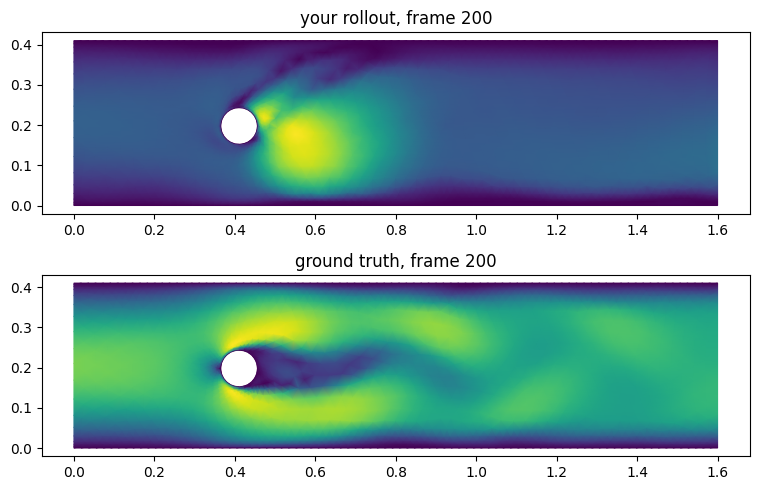

In [13]:
model.eval()
with torch.no_grad():
    v = velT[0].clone(); pred = [v.clone()]
    for t in range(1, 300):
        nf = node_norm(torch.cat([v, onehot], 1), acc=False)
        ef = edge_norm(edge_feats, acc=False)
        v = v + out_norm.inv(model(nf, ef, edge_index))        # step forward one frame
        v[~mask] = velT[t][~mask]                              # pin boundary nodes to truth
        pred.append(v.clone())
    pred = torch.stack(pred)

f = 200
t = mtri.Triangulation(pos[:,0].cpu(), pos[:,1].cpu(), cells)
fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].tripcolor(t, pred[f].norm(dim=1).cpu().numpy(), shading="gouraud")
ax[0].set_aspect("equal"); ax[0].set_title("your rollout, frame 200")
ax[1].tripcolor(t, velT[f].norm(dim=1).cpu().numpy(), shading="gouraud")
ax[1].set_aspect("equal"); ax[1].set_title("ground truth, frame 200")
plt.tight_layout(); plt.show()

device: cuda
meta.json 0 KB
downloading train.tfrecord ...
train.tfrecord 13325981 KB
test.tfrecord 1323609 KB
training...
epoch   0   loss 0.0488
epoch   1   loss 0.0413
epoch   2   loss 0.0404
epoch   3   loss 0.0405
epoch   4   loss 0.0420
epoch   5   loss 0.0390
epoch   6   loss 0.0428
epoch   7   loss 0.0372
epoch   8   loss 0.0403
epoch   9   loss 0.0345
epoch  10   loss 0.0399
epoch  11   loss 0.0380
epoch  12   loss 0.0383
epoch  13   loss 0.0403
epoch  14   loss 0.0346
saved mgn.pt
rolled 300 steps in 5.04s  (59 steps/s)


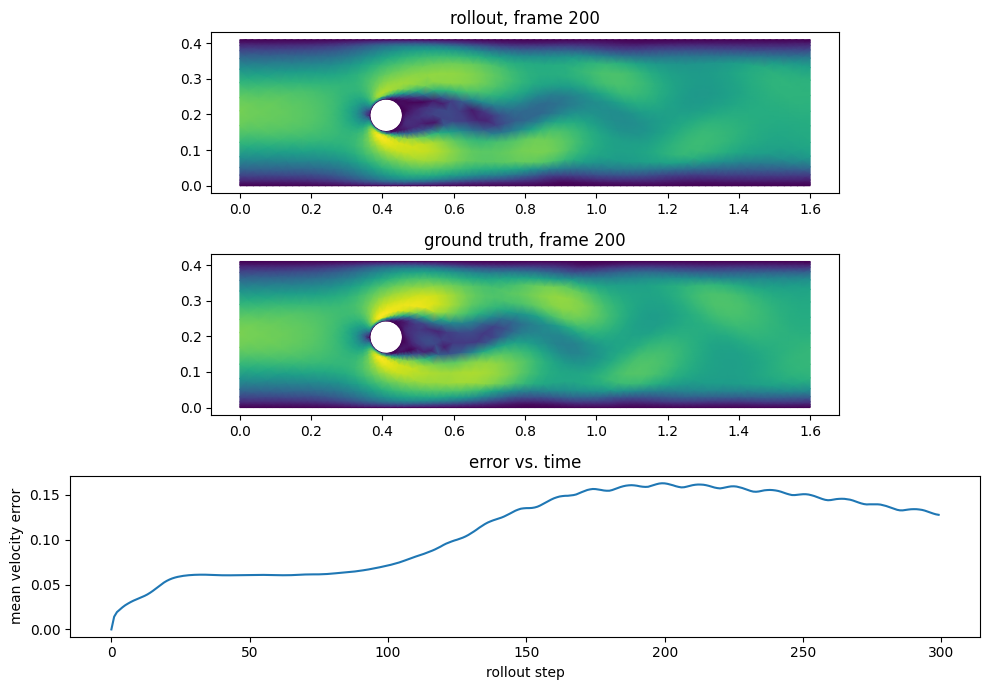

final-frame mean error: 0.1276


In [14]:
"""
MeshGraphNet on DeepMind cylinder_flow — full pipeline.
Requires: torch, tensorflow (CPU is fine, only used to parse the data), matplotlib, numpy.
Run top to bottom. On a strong GPU, raise EPOCHS / STEPS_PER_TRAJ and let it run for hours.
"""
import os, json, time, urllib.request
import numpy as np, torch, torch.nn as nn
import tensorflow as tf
import matplotlib.pyplot as plt, matplotlib.tri as mtri

# ----------------------------- config (tune these) -----------------------------
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
LAT             = 128       # latent width  (paper setting — leave as is)
N_BLOCKS        = 15        # message-passing rounds (paper setting — leave as is)
EPOCHS          = 15        # raise for better results (overnight = many more)
STEPS_PER_TRAJ  = 30        # gradient steps sampled per trajectory
NOISE           = 0.02      # input noise for rollout stability — sweep 0.01..0.05
LR              = 1e-3
ROLLOUT_STEPS   = 300
print("device:", DEVICE)

# ----------------------------- 1. download data --------------------------------
BASE = "https://storage.googleapis.com/dm-meshgraphnets/cylinder_flow/"
os.makedirs("cf", exist_ok=True)
for f in ["meta.json", "train.tfrecord", "test.tfrecord"]:      # train is several GB
    p = f"cf/{f}"
    if not os.path.exists(p):
        print("downloading", f, "...")
        urllib.request.urlretrieve(BASE + f, p)
    print(f, os.path.getsize(p) // 1024, "KB")

meta = json.load(open("cf/meta.json"))

# ----------------------------- 2. parse (DeepMind format) ----------------------
def parse(proto, meta):
    feats = {k: tf.io.VarLenFeature(tf.string) for k in meta["field_names"]}
    d = tf.io.parse_single_example(proto, feats)
    out = {}
    for key, field in meta["features"].items():
        x = tf.io.decode_raw(d[key].values, getattr(tf, field["dtype"]))
        x = tf.reshape(x, field["shape"])
        if field["type"] == "static":
            x = tf.tile(x, [meta["trajectory_length"], 1, 1])
        out[key] = x
    return out

# ----------------------------- 3. build graph per trajectory -------------------
# Each trajectory has its OWN mesh, so features must be rebuilt every time.
def build_graph(traj, device):
    pos   = torch.tensor(traj["mesh_pos"][0].numpy())
    cells = traj["cells"][0].numpy().astype("int64")
    ntype = torch.tensor(traj["node_type"][0].numpy()).squeeze(-1).long()
    velT  = torch.tensor(traj["velocity"].numpy()).to(device)      # [T, n, 2]
    c = torch.tensor(cells)
    e = torch.cat([c[:, [0,1]], c[:, [1,2]], c[:, [2,0]]], 0)
    e = torch.cat([e, e.flip(1)], 0).unique(dim=0)                 # bidirectional
    ei = e.t().contiguous().to(device); s, d = ei
    pos = pos.to(device); rel = pos[s] - pos[d]
    ef = torch.cat([rel, rel.norm(dim=1, keepdim=True)], 1)        # rel pos + distance
    oh = torch.nn.functional.one_hot(ntype.to(device), 9).float()
    mask = velT.std(0).norm(dim=1) > 1e-8                          # moving (interior) nodes
    return velT, ei, ef, oh, mask, pos, cells

# ----------------------------- 4. model ----------------------------------------
def mlp(i, o, h=LAT): return nn.Sequential(nn.Linear(i, h), nn.ReLU(), nn.Linear(h, o))

class GraphNetBlock(nn.Module):
    def __init__(self, lat=LAT):
        super().__init__()
        self.edge_mlp = mlp(3*lat, lat)      # [edge, sender, receiver]
        self.node_mlp = mlp(2*lat, lat)      # [node, summed messages]
    def forward(self, h_node, h_edge, edge_index):
        s, d = edge_index
        e_upd = self.edge_mlp(torch.cat([h_edge, h_node[s], h_node[d]], 1))   # message
        agg   = torch.zeros_like(h_node).index_add_(0, d, e_upd)              # gather
        v_upd = self.node_mlp(torch.cat([h_node, agg], 1))                    # update
        return h_node + v_upd, h_edge + e_upd                                 # residual

class MeshGraphNet(nn.Module):
    def __init__(self, n_node_f, n_edge_f, lat=LAT, n_blocks=N_BLOCKS):
        super().__init__()
        self.ne = mlp(n_node_f, lat); self.ee = mlp(n_edge_f, lat)
        self.blocks = nn.ModuleList([GraphNetBlock(lat) for _ in range(n_blocks)])
        self.decoder = mlp(lat, 2)
    def forward(self, node_feats, edge_feats, edge_index):
        h_node = self.ne(node_feats); h_edge = self.ee(edge_feats)
        for blk in self.blocks:
            h_node, h_edge = blk(h_node, h_edge, edge_index)
        return self.decoder(h_node)          # [n, 2] velocity change

class Norm(nn.Module):                       # running mean/std standardizer
    def __init__(self, sz):
        super().__init__()
        self.register_buffer("su", torch.zeros(sz))
        self.register_buffer("sq", torch.zeros(sz))
        self.register_buffer("c",  torch.zeros(1))
    def stats(self):
        m = self.su / self.c.clamp(min=1)
        return m, (self.sq / self.c.clamp(min=1) - m*m).clamp(min=1e-8).sqrt()
    def forward(self, x, acc=True):
        if acc:
            self.su += x.sum(0); self.sq += (x*x).sum(0); self.c += x.shape[0]
        m, sd = self.stats(); return (x - m) / sd
    def inv(self, x):
        m, sd = self.stats(); return x * sd + m

# ----------------------------- 5. train on the full dataset --------------------
model = MeshGraphNet(2+9, 3).to(DEVICE)
node_norm, edge_norm, out_norm = Norm(11).to(DEVICE), Norm(3).to(DEVICE), Norm(2).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), LR)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9999)
lossf = nn.MSELoss()
train_ds = tf.data.TFRecordDataset("cf/train.tfrecord").map(lambda p: parse(p, meta))

print("training...")
for epoch in range(EPOCHS):
    last = 0.0
    for traj in train_ds:
        velT, ei, ef, oh, mask, pos, cells = build_graph(traj, DEVICE)
        for _ in range(STEPS_PER_TRAJ):
            t = np.random.randint(0, velT.shape[0] - 1)
            v = velT[t] + torch.randn(velT.shape[1], 2, device=DEVICE) * NOISE
            nf  = node_norm(torch.cat([v, oh], 1)); ee = edge_norm(ef)
            tgt = out_norm(velT[t+1] - v)
            loss = lossf(model(nf, ee, ei)[mask], tgt[mask])
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            last = loss.item()
    print(f"epoch {epoch:3d}   loss {last:.4f}")

torch.save(model.state_dict(), "mgn.pt")        # keep the trained weights
print("saved mgn.pt")

# ----------------------------- 6. rollout on a test trajectory -----------------
test_ds = tf.data.TFRecordDataset("cf/test.tfrecord").map(lambda p: parse(p, meta))
traj = next(iter(test_ds))
velT, ei, ef, oh, mask, pos, cells = build_graph(traj, DEVICE)

model.eval()
t0 = time.time()
with torch.no_grad():
    v = velT[0].clone(); pred = [v.clone()]
    for t in range(1, ROLLOUT_STEPS):
        nf = node_norm(torch.cat([v, oh], 1), acc=False); ee = edge_norm(ef, acc=False)
        v = v + out_norm.inv(model(nf, ee, ei))
        v[~mask] = velT[t][~mask]                # pin boundary nodes to ground truth
        pred.append(v.clone())
    pred = torch.stack(pred)
infer_s = time.time() - t0
print(f"rolled {ROLLOUT_STEPS} steps in {infer_s:.2f}s  ({ROLLOUT_STEPS/infer_s:.0f} steps/s)")

# ----------------------------- 7. evaluate: panels + error curve ---------------
gt = velT[:ROLLOUT_STEPS]
err = (pred - gt).norm(dim=2).mean(dim=1).cpu().numpy()   # mean node error per frame

tri = mtri.Triangulation(pos[:, 0].cpu(), pos[:, 1].cpu(), cells)
f = min(200, ROLLOUT_STEPS - 1)
fig, ax = plt.subplots(3, 1, figsize=(10, 7))
ax[0].tripcolor(tri, pred[f].norm(dim=1).cpu().numpy(), shading="gouraud")
ax[0].set_aspect("equal"); ax[0].set_title(f"rollout, frame {f}")
ax[1].tripcolor(tri, gt[f].norm(dim=1).cpu().numpy(), shading="gouraud")
ax[1].set_aspect("equal"); ax[1].set_title(f"ground truth, frame {f}")
ax[2].plot(err); ax[2].set_xlabel("rollout step"); ax[2].set_ylabel("mean velocity error")
ax[2].set_title("error vs. time")
plt.tight_layout(); plt.savefig("mgn_result.png", dpi=90); plt.show()
print("final-frame mean error:", round(float(err[-1]), 4))